In [2]:
pip install librosa numpy pandas matplotlib seaborn scikit-learn tensorflow


Note: you may need to restart the kernel to use updated packages.


In [24]:
import os
import zipfile
import librosa
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [32]:
ZIP_PATH = "Audio_speech_actors.zip"
EXTRACT_PATH = "Audio_speech_actors"


In [36]:
if not os.path.exists(EXTRACT_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [37]:
# Handle nested folders inside ZIP
contents = os.listdir(EXTRACT_PATH)

if len(contents) == 1 and os.path.isdir(os.path.join(EXTRACT_PATH, contents[0])):
    DATASET_PATH = os.path.join(EXTRACT_PATH, contents[0])
else:
    DATASET_PATH = EXTRACT_PATH

print("Using dataset path:", DATASET_PATH)
print("Folders found:", os.listdir(DATASET_PATH))


Using dataset path: Audio_speech_actors
Folders found: ['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24', 'audio_speech_actors_01-24']


In [42]:
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}


In [72]:
def extract_mfcc(file_path, max_len=174):
    audio, sr = librosa.load(file_path)  # full audio
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=60)  # 60 MFCCs
    mfcc = mfcc.T

    # Pad or truncate to max_len
    if mfcc.shape[0] < max_len:
        pad_width = max_len - mfcc.shape[0]
        mfcc = np.pad(mfcc, pad_width=((0, pad_width),(0,0)), mode='constant')
    else:
        mfcc = mfcc[:max_len, :]
    return mfcc



In [74]:
X = []
y = []

for actor in os.listdir(DATASET_PATH):
    actor_path = os.path.join(DATASET_PATH, actor)
    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):
        if file.endswith(".wav"):
            try:
                emotion_code = file.split("-")[2]
                emotion = emotion_map[emotion_code]
                file_path = os.path.join(actor_path, file)
                mfcc = extract_mfcc(file_path)
                X.append(mfcc)
                y.append(emotion)
            except Exception as e:
                print("Skipped file:", file)

X = np.array(X)
y = np.array(y)
print("Features shape:", X.shape)
print("Labels shape:", y.shape)



Features shape: (1440, 174, 60)
Labels shape: (1440,)


In [76]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_onehot = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)



In [78]:
model = Sequential([
    LSTM(256, return_sequences=True, input_shape=(174, 60)),
    Dropout(0.3),
    LSTM(128),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(y_onehot.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 174, 256)            │         324,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 174, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 128)                 │         197,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 530,504 (2.02 MB)

 Trainable params: 530,504 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32
)



Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 521ms/step - accuracy: 0.2023 - loss: 1.9671 - val_accuracy: 0.2951 - val_loss: 1.8228
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 450ms/step - accuracy: 0.3411 - loss: 1.7008 - val_accuracy: 0.3438 - val_loss: 1.6971
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 450ms/step - accuracy: 0.3819 - loss: 1.5810 - val_accuracy: 0.3681 - val_loss: 1.5561
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 458ms/step - accuracy: 0.4219 - loss: 1.4673 - val_accuracy: 0.3993 - val_loss: 1.5401
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 446ms/step - accuracy: 0.4792 - loss: 1.3656 - val_accuracy: 0.4618 - val_loss: 1.4454
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 452ms/step - accuracy: 0.5208 - loss: 1.2619 - val_accuracy: 0.4618 - val_loss: 1.3682
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 472ms/step - accuracy: 0.5738 - loss: 1.1731 - val_accuracy: 0.4410 - val_loss: 1.4458
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 490ms/step - accuracy: 0.5833 - loss: 1.1723 - val_accu

In [82]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)



9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.6146 - loss: 2.0319
Test Accuracy: 0.6145833134651184


In [84]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print(classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=encoder.classes_
))


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step
              precision    recall  f1-score   support

       angry       0.74      0.74      0.74        38
        calm       0.74      0.61      0.67        38
     disgust       0.60      0.63      0.62        38
     fearful       0.59      0.69      0.64        39
       happy       0.48      0.41      0.44        39
     neutral       0.61      0.58      0.59        19
         sad       0.45      0.50      0.47        38
   surprised       0.72      0.74      0.73        39

    accuracy                           0.61       288
   macro avg       0.62      0.61      0.61       288
weighted avg       0.62      0.61      0.61       288



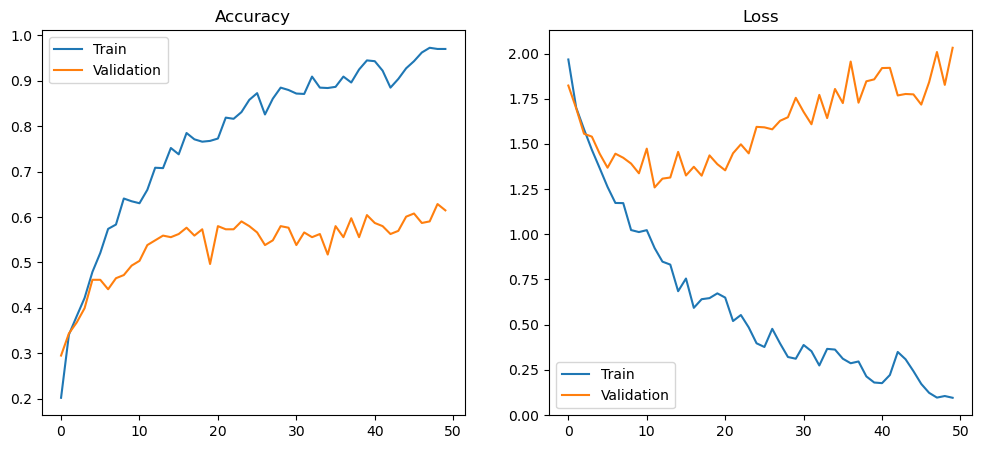

In [86]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.show()
